## Setting up remote LLM

In [1]:
import os, getpass
from dotenv import load_dotenv, find_dotenv

def ensure_env(var: str):
    """
    Ensure that a given environment variable is set.
    1. Try to load from .env.local if it exists.
    2. If not found, ask the user securely.
    """
    dotenv_path = find_dotenv(".env.local")
    if dotenv_path:
        load_dotenv(dotenv_path)

    value = os.getenv(var)
    if not value:
        value = getpass.getpass(f"Enter value for {var}: ")
        os.environ[var] = value

    return value


# Example: choose which variable you need
key = ensure_env("OPENAI_API_KEY")
# key = ensure_env("GOOGLE_API_KEY")


# Example usage
from langchain_openai import ChatOpenAI
openai_llm = ChatOpenAI(model="gpt-4o")
result = openai_llm.invoke("Hello world")
print(result.content)


# from langchain_google_genai import ChatGoogleGenerativeAI
# google_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
# result = google_llm.invoke("Hello world")
# print(result.content)

/Users/per287/Documents/Conferences/ICMI2025/Human_AI_Tutorial/icmi-multimodal-ai-agents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hello! How can I assist you today?


In [2]:
llm = openai_llm

## Let's create simple MCP server first

Simple example `arithmetic_mcp.py`

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage, HumanMessage


# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


# Set up MCP client
client = MultiServerMCPClient(
    {
        "math": {
            "command": "python",
            "args": ["./arithmetic_mcp.py"],
            "transport": "stdio",
        },
        "weather": {
            # start this mcp server first
            "url": "http://localhost:8053/mcp/",
            "transport": "streamable_http",
        }
    }
)

tools = await client.get_tools()
print(f'tools------: {tools}')

# Bind tools to model
model_with_tools = llm.bind_tools(tools)


tools------: [StructuredTool(name='add', description='Add two numbers', args_schema={'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'addArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x11ba27600>), StructuredTool(name='multiply', description='Multiply two numbers', args_schema={'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiplyArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x10c9a4d60>)]


In [4]:
from langgraph.prebuilt import ToolNode

# Create ToolNode
tool_node = ToolNode(tools)

def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

# The first agent node
async def call_model(state: MessagesState):
    messages = state["messages"]
    response = await model_with_tools.ainvoke(messages)
    return {"messages": [response]}


In [5]:
from langgraph.prebuilt import tools_condition


# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("Agent1", call_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "Agent1")
# builder.add_conditional_edges(
#     "Agent1",
#     should_continue,
#     ["tools", END],
# )
builder.add_conditional_edges(
    "Agent1",
    tools_condition,
)

builder.add_edge("tools", "Agent1")

# Compile the graph
graph = builder.compile()


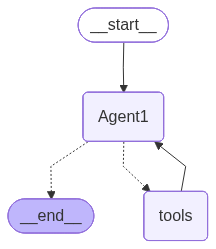

In [6]:
# ------------------------ visualise graph
from IPython.display import Image, display
import nest_asyncio # Required for Jupyter Notebook to run async functions
nest_asyncio.apply()

from langchain_core.runnables.graph import MermaidDrawMethod

try:
    img_data = graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

    display(Image(data=img_data, width=250))  #Change width to scale
except Exception as e:
    print("Could not display graph:", e)



In [7]:
# ------------------------ Test the graph

messages = [HumanMessage(content="(8+2) + (7+3) * 5")]
messages = await graph.ainvoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

# math_response = await graph.ainvoke(
#     {"messages": [{"role": "user", "content": "what's (3 + 5) x 12?"}]}
# )

================================ Human Message =================================

(8+2) + (7+3) * 5
================================== Ai Message ==================================
Tool Calls:
  add (call_wec0QFA6XtbEW30fJFasTUlH)
 Call ID: call_wec0QFA6XtbEW30fJFasTUlH
  Args:
    a: 8
    b: 2
  add (call_aH3TYMWU67Jtp9KXnbe9aVa5)
 Call ID: call_aH3TYMWU67Jtp9KXnbe9aVa5
  Args:
    a: 7
    b: 3
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================
Tool Calls:
  multiply (call_i1aLL0K7yBt1IodiMo1N5YoS)
 Call ID: call_i1aLL0K7yBt1IodiMo1N5YoS
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ==================================
Tool Calls:
  add (call_n

### Now let's add a remote MCP servers

In [ ]:
# Set up MCP client
client = MultiServerMCPClient(
    {
        "weather": {
            # start this mcp server first
            "url": "http://localhost:8053/mcp/",
            "transport": "streamable_http",
        }
    }
)
tools = await client.get_tools()
print(f'tools------: {tools}')

# Bind tools to model
model_with_tools = llm.bind_tools(tools)
